In [91]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape


In [5]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "test"

In [13]:
def meta_one_hot_shot(meta, para_nm):
    meta = meta.transpose()
    meta_one_hot = pd.DataFrame(False, index=meta.index, columns=para_nm)
    for index, row in meta.iterrows():
        for r in row.values:
            meta_one_hot.loc[index, para_nm[r]] = True

    return meta_one_hot

In [15]:
class EmulatedDataStorage:
    """
    Lightweight container for emulation outputs.
    No computation logic.
    """
    def __init__(self):
        pass

In [73]:

def group_para_climatology(tf_masks, para_nm, meta, threshold = 5000):

    vars = list(tf_masks.columns)

    paras_vars = {}

    for c in vars: 
        para_inds = meta[c].sort_values()
        para_nms = list(para_nm[para_inds])
        paras_vars.setdefault(tuple(para_nms), []).append(c)

        
    return paras_vars

In [115]:
class HistoryMatching:
    def __init__(self, working_dir, case_name, threshold_level = 2.0):
        self.root = Path(working_dir) / case_name
        self.tf_masks = pd.read_csv(self.root / f'tf_masks_level_{threshold_level}.csv', index_col=0)
        self.meta = pd.read_csv(self.root / 'meta.csv', index_col = 0)
        self.p_emu = xr.open_dataset(self.root / 'sampled_parameters.nc').to_dataframe()
        self.var_nm = list(self.tf_masks.columns)
        self.para_nm = list(self.p_emu.columns)

        self.tf_masks_raw = self.tf_masks

        self.dropped_vars = EmulatedDataStorage()
        self.n_sample = self.tf_masks.shape[0]
        
    def drop_by_name(self, var_to_exclude):
        var_to_drop = []
        for v in var_to_exclude:
            var_to_drop.extend([s for s in self.var_nm if s.startswith(v)])

        print("Drop the following variables")
        print(var_to_drop)
        
        self.tf_masks = self.tf_masks.drop(columns = var_to_drop)

        self.var_nm = list(self.tf_masks.columns)
        self.dropped_vars.by_name = var_to_drop

    def drop_by_n_survive(self, n_survive):
        survive_summary = self.tf_masks.sum(axis = 0)
        self.dropped_vars.useless = list(survive_summary[survive_summary == self.n_sample].index)
        self.dropped_vars.tight   = list(survive_summary[survive_summary < n_survive].index)

        self.tf_masks = self.tf_masks.drop(columns = self.dropped_vars.useless + self.dropped_vars.tight)
        
        self.var_nm = list(self.tf_masks.columns)

    def update_meta(self, occurence_threshold = 2):
        self.meta = self.meta[self.var_nm]
        self.meta_onehot = meta_one_hot_shot(self.meta, self.para_nm)
        p_occur_count = self.meta_onehot.sum(axis = 0)
        self.p_occur_count = p_occur_count
        
        p_sensitive = list(p_occur_count[p_occur_count > occurence_threshold].index)
        self.meta_onehot = self.meta_onehot[p_sensitive]

    def hull_for_each(self, shape_alpha = 5):
        hull_per_var = {}
        for v in self.var_nm:
            p_ind = self.meta[v].sort_values().values
            pts = self.p_emu[self.tf_masks[v]].iloc[:,p_ind]
            if pts.shape[0] > 5000:
               pts = pts.sample(5000)

            pts = pts.values
            
            hull_per_var[v] = alphashape.alphashape(pts, shape_alpha)

        self.hull_per_var = hull_per_var

In [116]:
test_case = HistoryMatching(working_dir, case_name)

In [117]:
test_case.drop_by_name(["TGCLDLWP", "CLDTOT"])

Drop the following variables
['TGCLDLWP_zonal_30to35', 'TGCLDLWP_zonal_40to45', 'TGCLDLWP_zonal_-65to-60', 'TGCLDLWP_zonal_-60to-55', 'TGCLDLWP_zonal_0to5', 'TGCLDLWP_zonal_-40to-35', 'TGCLDLWP_zonal_70to75', 'TGCLDLWP_zonal_-20to-15', 'TGCLDLWP_zonal_65to70', 'TGCLDLWP_zonal_-45to-40', 'TGCLDLWP_zonal_55to60', 'TGCLDLWP_zonal_35to40', 'TGCLDLWP_zonal_25to30', 'TGCLDLWP_zonal_50to55', 'TGCLDLWP_zonal_-25to-20', 'TGCLDLWP_zonal_-10to-5', 'TGCLDLWP_zonal_45to50', 'TGCLDLWP_zonal_-70to-65', 'TGCLDLWP_zonal_-35to-30', 'TGCLDLWP_zonal_-50to-45', 'TGCLDLWP_zonal_15to20', 'TGCLDLWP_zonal_-75to-70', 'TGCLDLWP_zonal_10to15', 'TGCLDLWP_zonal_-55to-50', 'TGCLDLWP_zonal_60to65', 'TGCLDLWP_zonal_-15to-10', 'TGCLDLWP_zonal_-5to0', 'TGCLDLWP_zonal_20to25', 'TGCLDLWP_zonal_-30to-25', 'CLDTOT_ISCCP_zonal_-35to-30', 'CLDTOT_ISCCP_zonal_-30to-25', 'CLDTOT_ISCCP_zonal_-45to-40', 'CLDTOT_ISCCP_zonal_-55to-50', 'CLDTOT_ISCCP_zonal_20to25', 'CLDTOT_ISCCP_zonal_25to30', 'CLDTOT_ISCCP_zonal_-40to-35', 'CLDTOT_

In [118]:
test_case.drop_by_n_survive(n_survive = 100000)

In [119]:
test_case.update_meta()

In [128]:
test_case.hull_for_each()

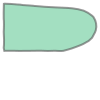

In [129]:
test_case.hull_per_var['SWCF_zonal_65to70']

In [84]:
p_ind = test_case.meta[v].sort_values().values
test_case.p_emu[test_case.tf_masks[v]].iloc[:,p_ind].values

array([[0.47783801, 0.1312594 ],
       [0.21826854, 0.09056803],
       [0.33771919, 0.15662527],
       ...,
       [0.3677732 , 0.1287083 ],
       [0.16999383, 0.05485007],
       [0.34839158, 0.02240959]])

In [79]:
test_case.p_emu[test_case.tf_masks['SWCF_zonal_65to70']]

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
index,,,,,,,,,,,,,,,,,,,,,
0,0.733874,0.328050,0.344609,0.885443,0.544743,0.501783,0.875125,0.364051,0.477838,0.614800,...,0.000521,0.890155,0.467158,0.097406,0.704333,0.601954,0.948462,0.131259,0.499465,0.413951
10,0.517836,0.159608,0.124167,0.582220,0.497356,0.399957,0.614859,0.192114,0.218269,0.790377,...,0.627784,0.082068,0.657603,0.097603,0.663141,0.945226,0.580878,0.090568,0.927281,0.380705
24,0.387889,0.738223,0.669492,0.113151,0.161354,0.397332,0.826103,0.376676,0.337719,0.146114,...,0.752563,0.777973,0.585733,0.516777,0.161751,0.585818,0.656661,0.156625,0.651671,0.822021
26,0.257826,0.070106,0.066351,0.629231,0.099491,0.093373,0.639229,0.009460,0.052093,0.348609,...,0.977598,0.129332,0.539848,0.177778,0.517130,0.097026,0.604494,0.119394,0.561492,0.531136
34,0.100137,0.793847,0.259234,0.758763,0.988803,0.825708,0.431605,0.295762,0.193974,0.498353,...,0.218097,0.658284,0.557158,0.602016,0.407885,0.754795,0.327520,0.114854,0.862529,0.560947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999922,0.811245,0.621473,0.096659,0.347311,0.105644,0.717854,0.252663,0.273791,0.004082,0.406758,...,0.236858,0.445643,0.159447,0.141860,0.269388,0.932964,0.307401,0.011798,0.779832,0.028026
999946,0.874316,0.722566,0.244379,0.526099,0.946950,0.237175,0.180546,0.369160,0.216936,0.375708,...,0.535460,0.159147,0.971327,0.892075,0.965267,0.081853,0.408661,0.203122,0.296177,0.384184
999979,0.908780,0.523992,0.584692,0.521495,0.586896,0.261008,0.010884,0.616138,0.367773,0.437928,...,0.690812,0.888020,0.036798,0.719411,0.855180,0.805765,0.067249,0.128708,0.979207,0.659674


In [62]:
aa = test_case.meta_onehot.sum(axis = 0)
list(aa[aa > 0].index)

['micro_mg_berg_eff_factor',
 'clubb_c1',
 'clubb_C8',
 'clubb_c14',
 'clubb_gamma_coef',
 'clubb_c2rt',
 'zmconv_ke',
 'zmconv_dmpdz',
 'cldfrc_dp1',
 'cldfrc_dp2',
 'zmconv_capelmt',
 'seasalt_emis_scale',
 'dust_emis_fact',
 'microp_aero_wsub_min',
 'microp_aero_wsub_scale',
 'microp_aero_wsubi_scale']

In [39]:
len(test_case.dropped_vars.tight)

48

In [44]:
len(test_case.var_nm)

106

In [26]:
len(test_case.var_nm) + len(test_case.dropped_vars.by_name)+ len(test_case.dropped_vars.tight)+ len(test_case.dropped_vars.useless)

235

In [ ]:
def meta_one_hot_shot(meta, para_nm):
    meta = meta.transpose()
    meta_one_hot = pd.DataFrame(False, index=meta.index, columns=para_nm)
    for index, row in meta.iterrows():
        for r in row.values:
            meta_one_hot.loc[index, para_nm[r]] = True

    return meta_one_hot